# Oasis Infobyte Data Analytics Internship

## Task 1: Exploratory Data Analysis (EDA) on Retail Sales Data

### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer demographics, purchasing behavior, and business insights. The analysis is performed using Python libraries such as Pandas, Matplotlib, and Seaborn.

In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Plot style
sns.set_style("whitegrid")

# Figure size
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# Display First Five Rows

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Initial Dataset Inspection

Before performing any analysis, it is important to understand the structure of the dataset. This includes checking the number of rows and columns, data types, missing values, and available features.

In [ ]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 9


### Observation

The dataset contains **1000 transactions** and **9 columns**, providing sufficient information for performing exploratory data analysis.

In [ ]:
# Display Column Names

df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

### Observation

The dataset includes customer information, transaction details, product categories, purchase quantity, unit price, and total purchase amount. These variables will be used to analyze customer behavior and sales performance.

In [ ]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Observation

The dataset contains both numerical and categorical variables. The 'Date' column will be converted into datetime format for time series analysis. The dataset structure is suitable for performing statistical and visual analysis.

In [ ]:
# Convert Date Column

df["Date"] = pd.to_datetime(df["Date"])

print("Date column converted successfully!")

Date column converted successfully!


## Missing Value Analysis

Missing values can affect the quality of analysis. Therefore, it is important to verify whether the dataset contains any null values before proceeding further.

In [ ]:
# Check Missing Values

df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


### Observation

No missing values were found in the dataset. Therefore, no data cleaning or imputation is required before analysis.


# Descriptive Statistics

Descriptive statistics summarize the numerical features by showing measures such as mean, median, mode, minimum, maximum, and standard deviation.

In [ ]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

numerical_summary = df.describe()

numerical_summary

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [ ]:
# Mean

df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [ ]:
# Median

df.median(numeric_only=True)

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [ ]:
# Mode

df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [ ]:
# Standard Deviation

df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


### Observation

The descriptive statistics indicate variations in customer age, purchase quantity, price per unit, and total purchase amount. The average transaction value and dispersion of numerical variables provide useful insights into customer purchasing behavior.

### Observation

The dataset does not contain any missing values in any column. Therefore, no data imputation or removal is required before performing further analysis.

# Time Series Analysis

Time series analysis helps understand how sales change over time. In this section, monthly and quarterly sales trends are analyzed using line charts.

In [ ]:
# ==========================================================
# Extract Month and Quarter from Date
# ==========================================================

df["Month"] = df["Date"].dt.month_name()
df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

print("Month and Quarter columns created successfully!")

Month and Quarter columns created successfully!


In [ ]:
# Arrange months in calendar order

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("Month")["Total Amount"]
      .sum()
      .reindex(month_order)
)

monthly_sales

,Total Amount
Month,
January,36980
February,44060
March,28990
April,33870
May,53150
June,36715
July,35465
August,36960
September,23620


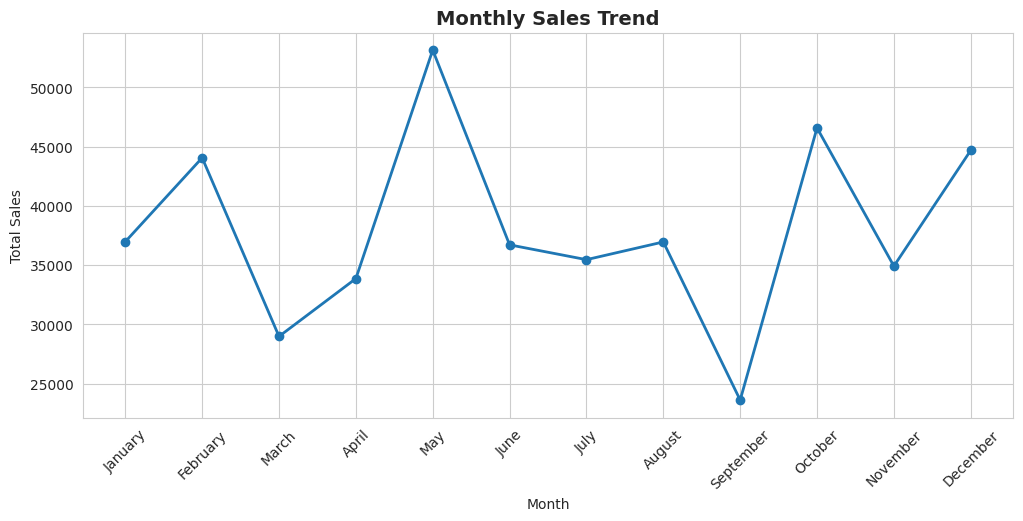

In [ ]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend",fontsize=14,fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

The monthly sales trend shows how revenue changes throughout the year. Some months record higher sales, indicating periods of increased customer purchasing activity.

### Business Insight

The business should identify the reasons behind high-performing months and apply similar promotional strategies during lower-performing months.

In [ ]:
# Quarterly Sales

quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
      .sum()
)

quarterly_sales

,Total Amount
Quarter,
Q1,110030
Q2,123735
Q3,96045
Q4,126190


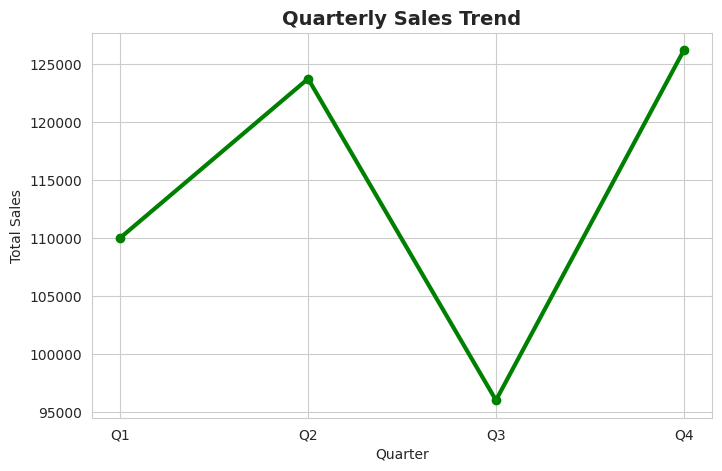

In [ ]:
# ==========================================================
# Quarterly Sales Trend
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o",
    linewidth=3,
    color="green"
)

plt.title("Quarterly Sales Trend",fontsize=14,fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

### Observation

The quarterly sales trend summarizes revenue over each quarter of the year. It helps identify seasonal sales patterns and business performance across different periods.

### Business Insight

Quarterly analysis enables businesses to plan inventory, marketing campaigns, and budgeting based on seasonal demand.

# Customer Demographics Analysis

Customer demographics help businesses understand the characteristics of their customers. In this section, customer age groups and gender distribution are analyzed to identify the major customer segments.

In [ ]:
# ==========================================================
# Create Age Groups
# ==========================================================

age_bins = [0, 18, 25, 35, 45, 55, 100]
age_labels = [
    "Below 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "55+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,Q4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,Q1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,Q1,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,Q2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,Q2,26-35


In [ ]:
# Count customers in each age group

age_group_count = (
    df["Age Group"]
    .value_counts()
    .sort_index()
)

age_group_count

,count
Age Group,
Below 18,21
18-25,148
26-35,205
36-45,202
46-55,229
55+,195


/tmp/ipykernel_1000/3153055435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


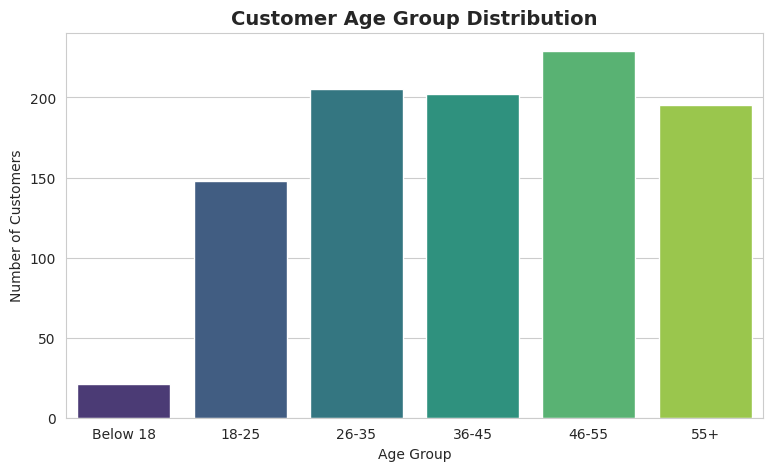

In [ ]:
# ==========================================================
# Age Group Distribution
# ==========================================================

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Age Group",
    order=age_labels,
    palette="viridis"
)

plt.title("Customer Age Group Distribution",fontsize=14,fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The age group distribution shows which customer age range contributes the highest number of transactions.

### Business Insight

Marketing campaigns can be targeted toward the dominant age group while designing separate promotional strategies for underrepresented age groups.

In [ ]:
# Gender Distribution

gender_count = df["Gender"].value_counts()

gender_count

,count
Gender,
Female,510
Male,490


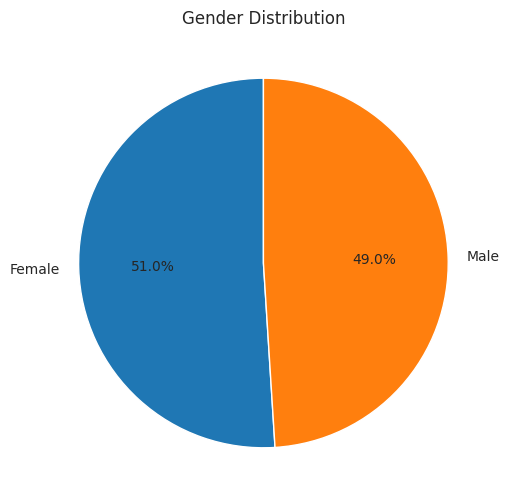

In [ ]:
# ==========================================================
# Gender Breakdown
# ==========================================================

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

### Observation

The gender distribution illustrates the percentage of male and female customers in the dataset.

### Business Insight

Understanding gender distribution helps businesses design targeted advertising campaigns and product recommendations for different customer groups.

In [ ]:
# ==========================================================
# Average Spending by Gender
# ==========================================================

gender_sales = (
    df.groupby("Gender")["Total Amount"]
      .mean()
)

gender_sales

,Total Amount
Gender,
Female,456.549020
Male,455.428571


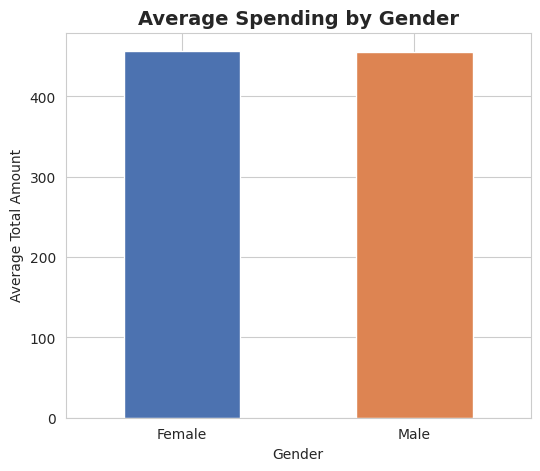

In [ ]:
# Average Spending by Gender

plt.figure(figsize=(6,5))

gender_sales.plot(
    kind="bar",
    color=["#4C72B0", "#DD8452"]
)

plt.title("Average Spending by Gender",fontsize=14,fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Average Total Amount")

plt.xticks(rotation=0)

plt.show()

### Observation

The chart compares the average spending of male and female customers. It helps identify which customer group spends more on average.

### Business Insight

If one gender has a higher average purchase value, the company can design personalized offers and loyalty programs to maximize revenue.

# Product Analysis

Product analysis helps identify which product categories contribute the most to total revenue. Since the dataset contains product categories rather than individual product names, the analysis focuses on category-level performance and the highest-value transactions.

In [ ]:
# ==========================================================
# Revenue by Product Category
# ==========================================================

category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


/tmp/ipykernel_1000/77598774.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


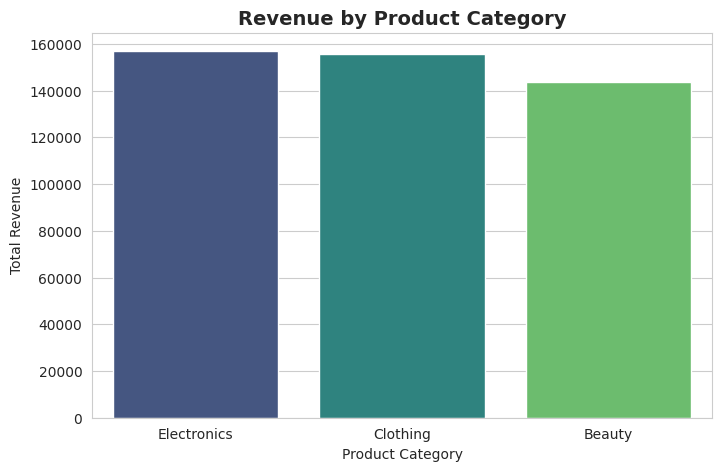

In [ ]:
# Revenue by Product Category

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Revenue by Product Category",fontsize=14,fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.show()

### Observation

The chart compares total revenue generated by each product category.

### Business Insight

The category generating the highest revenue should receive greater inventory planning and marketing investment to maximize business growth.

## Top 10 Highest Revenue Transactions

The dataset does not include individual product names. Therefore, the analysis identifies the top 10 highest-value transactions based on the total purchase amount.

In [ ]:
# ==========================================================
# Top 10 Highest Revenue Transactions
# ==========================================================

top10_transactions = (
    df.nlargest(10,"Total Amount")
)

top10_transactions[
    [
        "Transaction ID",
        "Date",
        "Gender",
        "Age",
        "Product Category",
        "Quantity",
        "Total Amount"
    ]
]

,Transaction ID,Date,Gender,Age,Product Category,Quantity,Total Amount
14,15,2023-01-16,Female,42,Electronics,4,2000
64,65,2023-12-05,Male,51,Electronics,4,2000
71,72,2023-05-23,Female,20,Electronics,4,2000
73,74,2023-11-22,Female,18,Beauty,4,2000
88,89,2023-10-01,Female,55,Electronics,4,2000
92,93,2023-07-14,Female,35,Beauty,4,2000
108,109,2023-10-18,Female,34,Electronics,4,2000
117,118,2023-05-16,Female,30,Electronics,4,2000
123,124,2023-10-27,Male,33,Clothing,4,2000
138,139,2023-12-15,Male,36,Beauty,4,2000


/tmp/ipykernel_1000/3937166092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


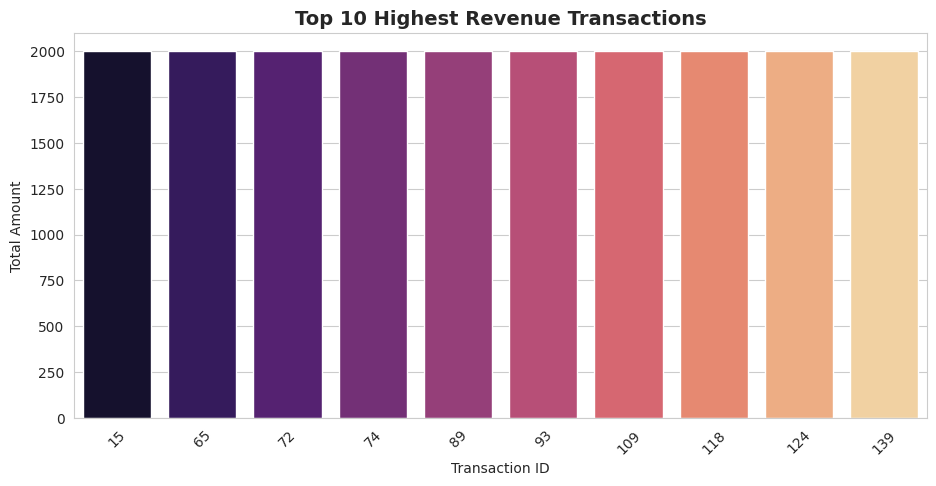

In [ ]:
# Top 10 Highest Revenue Transactions

plt.figure(figsize=(11,5))

sns.barplot(
    data=top10_transactions,
    x="Transaction ID",
    y="Total Amount",
    palette="magma"
)

plt.title("Top 10 Highest Revenue Transactions",fontsize=14,fontweight="bold")

plt.xticks(rotation=45)

plt.show()

### Observation

The visualization highlights the ten transactions with the highest purchase values.

### Business Insight

Understanding high-value purchases helps businesses identify premium buying patterns and design personalized marketing strategies for similar customers.

# Correlation Analysis

Correlation analysis measures the relationship between numerical variables and helps identify patterns among customer age, quantity purchased, unit price, and total purchase amount.

In [ ]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation = df[
    [
        "Age",
        "Quantity",
        "Price per Unit",
        "Total Amount"
    ]
].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


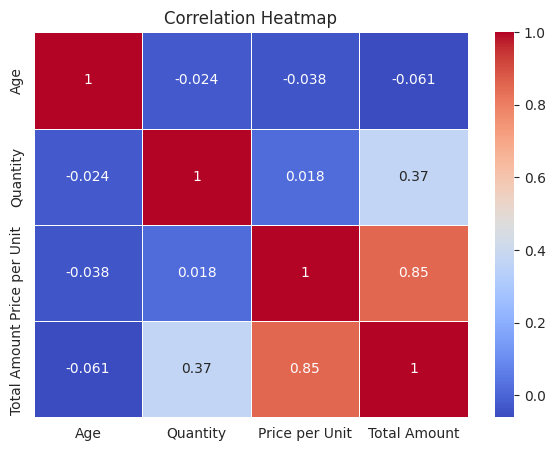

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap displays the strength and direction of relationships among the numerical variables.

### Business Insight

Variables with strong positive or negative correlations can guide pricing strategies, inventory management, and customer behavior analysis.

# Additional Visualization

The following visualization examines the relationship between customer age and total purchase amount.

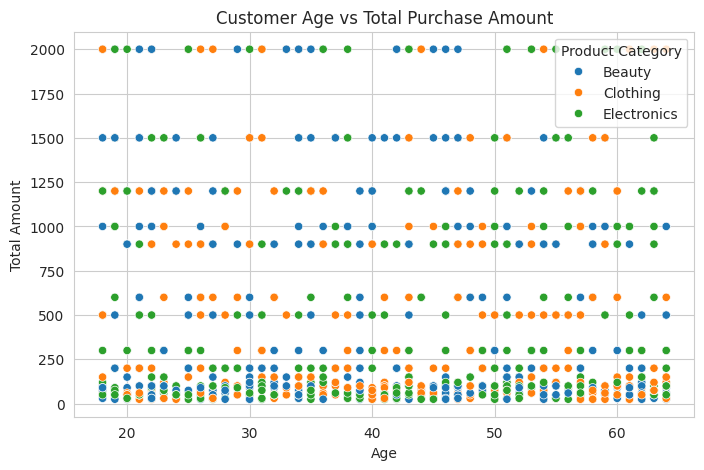

In [ ]:
# ==========================================================
# Age vs Total Amount
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total Amount",
    hue="Product Category"
)

plt.title("Customer Age vs Total Purchase Amount")

plt.show()

### Observation

The scatter plot illustrates how purchase amount varies across different age groups and product categories.

### Business Insight

This analysis helps identify whether certain age groups tend to spend more and whether specific product categories are more popular among particular customer segments.

# Key Findings

The Exploratory Data Analysis (EDA) provided valuable insights into customer purchasing behavior, product category performance, sales trends, and customer demographics.

The major findings obtained from the analysis are summarized below.

In [ ]:
# ==========================================================
# Summary Statistics
# ==========================================================

print("Total Revenue :", df["Total Amount"].sum())

print("Average Transaction Value :", round(df["Total Amount"].mean(),2))

print("Highest Transaction Value :", df["Total Amount"].max())

print("Lowest Transaction Value :", df["Total Amount"].min())

Total Revenue : 456000
Average Transaction Value : 456.0
Highest Transaction Value : 2000
Lowest Transaction Value : 25


### Observation

The summary statistics provide a quick overview of the business performance, including total revenue, average transaction value, and the range of customer purchases.

# Business Recommendations

Based on the analysis performed in this notebook, the following recommendations are suggested:

### 1. Focus on High-Revenue Product Categories
The product category generating the highest revenue should receive increased marketing efforts and inventory allocation.

### 2. Improve Sales During Low-Performing Months
Monthly sales analysis should be used to identify weaker months and launch promotional campaigns during those periods.

### 3. Design Customer-Centric Marketing
Age group and gender analysis can be used to create personalized marketing campaigns that target the most active customer segments.

### 4. Monitor High-Value Transactions
High-value transactions should be analyzed to understand customer preferences and encourage repeat purchases through loyalty programs.

### 5. Use Data for Business Decisions
Sales trends and customer behavior should be monitored regularly to support pricing strategies, inventory planning, and future business growth.

# Conclusion

This project successfully performed Exploratory Data Analysis (EDA) on a retail sales dataset using Python.

The analysis included:

- Initial dataset inspection
- Descriptive statistics
- Missing value analysis
- Monthly and quarterly sales trend analysis
- Customer demographics analysis
- Product category analysis
- Correlation analysis
- Data visualization
- Business recommendations

The insights obtained from this analysis can help businesses understand customer purchasing patterns, improve marketing strategies, optimize inventory management, and increase overall sales performance.

Overall, Exploratory Data Analysis proved to be an effective approach for transforming raw retail sales data into meaningful business insights.

# Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

# Thank You

**Submitted as part of the Oasis Infobyte Data Analytics Internship**

Prepared by:

**Name:** Pinapati Harish

**Internship:** Data Analytics Internship

**Organization:** Oasis Infobyte